In [1]:
!pip install gymnasium stable-baselines3 pandas numpy matplotlib seaborn openpyxl torch tqdm gym_anytrading

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.2/172.2 kB 5.6 MB/s eta 0:00:00


# Shanghai Index Reinforcement Learning Trading Strategy 

Using rich technical indicator features + optimized hyperparameters, test set: 2024-2025 data

In [2]:
from tqdm import tqdm
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import gym_anytrading
from gym_anytrading.envs import StocksEnv, Actions, Positions

from stable_baselines3 import A2C, PPO
from stable_baselines3.common.callbacks import BaseCallback

import torch

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## 1. Load and Preprocess Data

In [4]:
# Load data
df_raw = pd.read_excel('/content/drive/MyDrive/RL/output.xlsx')
df = df_raw.copy()
df = df.sort_values('trade_date', ascending=True).reset_index(drop=True)
df = df.rename(columns={'open': 'Open', 'close': 'Close', 'high': 'High', 'low': 'Low', 'vol': 'Volume'})
df['Date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df.set_index('Date', inplace=True)

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.tail()

数据形状: (8560, 13)
日期范围: 1990-12-19 00:00:00 至 2026-01-09 00:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ts_code,trade_date,Open,Close,High,Low,Volume,amount,amplitude,pct_chg,change,turnover,pre_close
Date,,,,,,,,,,,,,
2026-01-05,000001.SH,20260105,3986.97,4023.42,4025.26,3983.58,596950455,1.067334e+12,1.05,1.38,54.58,1.25,3968.84
2026-01-06,000001.SH,20260106,4026.02,4083.67,4083.67,4025.09,702472270,1.175769e+12,1.46,1.50,60.25,1.47,4023.42
2026-01-07,000001.SH,20260107,4083.84,4085.77,4098.78,4069.44,683384352,1.197423e+12,0.72,0.05,2.10,1.43,4083.67
2026-01-08,000001.SH,20260108,4077.72,4082.98,4093.87,4067.12,666131337,1.183189e+12,0.65,-0.07,-2.79,1.39,4085.77
2026-01-09,000001.SH,20260109,4086.76,4120.43,4121.72,4083.62,729837985,1.289206e+12,0.93,0.92,37.45,1.53,4082.98


## 2. Technical Indicator Calculation Functions

In [5]:
def compute_rsi(prices, period=14):
    """Calculate RSI indicator"""
    deltas = np.diff(prices)
    gains = np.where(deltas > 0, deltas, 0)
    losses = np.where(deltas < 0, -deltas, 0)

    avg_gains = np.zeros(len(prices))
    avg_losses = np.zeros(len(prices))

    if len(gains) >= period:
        avg_gains[period] = np.mean(gains[:period])
        avg_losses[period] = np.mean(losses[:period])

        for i in range(period + 1, len(prices)):
            avg_gains[i] = (avg_gains[i-1] * (period - 1) + gains[i-1]) / period
            avg_losses[i] = (avg_losses[i-1] * (period - 1) + losses[i-1]) / period

    rs = np.where(avg_losses != 0, avg_gains / avg_losses, 100)
    rsi = 100 - (100 / (1 + rs))
    rsi[:period] = 50
    return rsi

def compute_macd(prices, fast=12, slow=26, signal=9):
    """Calculate MACD indicator"""
    def ema(data, period):
        result = np.zeros(len(data))
        result[0] = data[0]
        multiplier = 2 / (period + 1)
        for i in range(1, len(data)):
            result[i] = (data[i] - result[i-1]) * multiplier + result[i-1]
        return result

    ema_fast = ema(prices, fast)
    ema_slow = ema(prices, slow)
    macd_line = ema_fast - ema_slow
    signal_line = ema(macd_line, signal)
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

def compute_bollinger_bands(prices, period=20, std_dev=2):
    """Calculate Bollinger Bands"""
    sma = np.convolve(prices, np.ones(period)/period, mode='same')
    rolling_std = np.array([np.std(prices[max(0,i-period+1):i+1]) if i >= period-1 else np.std(prices[:i+1]) for i in range(len(prices))])
    upper_band = sma + std_dev * rolling_std
    lower_band = sma - std_dev * rolling_std
    return upper_band, sma, lower_band

print("Technical indicator functions defined")

技术指标函数已定义


## 3. Create Enhanced Trading Environment

In [6]:
class ShanghaiIndexEnv(StocksEnv):
    """
    Shanghai Index Trading Environment - Enhanced Version
    Using rich technical indicator features + improved reward function
    """

    def __init__(self, df, window_size, frame_bound, render_mode=None):
        super().__init__(df, window_size, frame_bound, render_mode)
        self.trade_fee_bid_percent = 0.001  # Sell stamp duty 0.1%
        self.trade_fee_ask_percent = 0.0003  # Buy commission 0.03%

    def _process_data(self):
        # Get complete data
        full_close = self.df.loc[:, 'Close'].to_numpy()
        full_high = self.df.loc[:, 'High'].to_numpy()
        full_low = self.df.loc[:, 'Low'].to_numpy()
        full_open = self.df.loc[:, 'Open'].to_numpy()

        # Calculate moving averages
        ma5 = np.convolve(full_close, np.ones(5)/5, mode='same')
        ma10 = np.convolve(full_close, np.ones(10)/10, mode='same')
        ma20 = np.convolve(full_close, np.ones(20)/20, mode='same')
        ma60 = np.convolve(full_close, np.ones(60)/60, mode='same')

        # RSI
        rsi = compute_rsi(full_close, 14)

        # MACD
        macd_line, signal_line, macd_hist = compute_macd(full_close)

        # Bollinger Band
        bb_upper, bb_mid, bb_lower = compute_bollinger_bands(full_close, 20)

        # Extract data range
        start = self.frame_bound[0] - self.window_size
        end = self.frame_bound[1]

        prices = full_close[start:end]
        close = full_close[start:end]
        high = full_high[start:end]
        low = full_low[start:end]
        open_ = full_open[start:end]

        # Extract indicators
        ma5 = ma5[start:end]
        ma10 = ma10[start:end]
        ma20 = ma20[start:end]
        ma60 = ma60[start:end]
        rsi = rsi[start:end]
        macd_hist = macd_hist[start:end]
        bb_upper = bb_upper[start:end]
        bb_lower = bb_lower[start:end]

        # Normalize features
        eps = 1e-8

        # Price change percentage
        pct_change = np.insert(np.diff(close) / np.maximum(close[:-1], eps) * 100, 0, 0)

        # MA relative position (trend signal)
        ma5_ratio = (close - ma5) / np.maximum(ma5, eps) * 100
        ma10_ratio = (close - ma10) / np.maximum(ma10, eps) * 100
        ma20_ratio = (close - ma20) / np.maximum(ma20, eps) * 100
        ma60_ratio = (close - ma60) / np.maximum(ma60, eps) * 100

        # MA crossover signal
        ma5_10_cross = (ma5 - ma10) / np.maximum(ma10, eps) * 100
        ma10_20_cross = (ma10 - ma20) / np.maximum(ma20, eps) * 100

        # Bollinger Band position (0-100)
        bb_width = bb_upper - bb_lower
        bb_position = (close - bb_lower) / np.maximum(bb_width, eps) * 100
        bb_position = np.clip(bb_position, 0, 100)

        # RSI normalization
        rsi_norm = rsi / 100.0 * 2 - 1  # -1 to 1

        # MACD normalization
        macd_max = np.maximum(np.abs(macd_hist).max(), eps)
        macd_norm = macd_hist / macd_max

        # Amplitude
        amplitude = (high - low) / np.maximum(close, eps) * 100

        # Candlestick pattern
        body = (close - open_) / np.maximum(close, eps) * 100

        # Momentum indicator
        momentum_5 = np.zeros(len(close))
        momentum_5[5:] = (close[5:] - close[:-5]) / np.maximum(close[:-5], eps) * 100

        # Combined features (14 features)
        signal_features = np.column_stack((
            pct_change,       # 1. Daily price change
            ma5_ratio,        # 2. MA5 deviation
            ma10_ratio,       # 3. MA10 deviation
            ma20_ratio,       # 4. MA20 deviation
            ma60_ratio,       # 5. MA60 deviation
            ma5_10_cross,     # 6. MA5-10 crossover
            ma10_20_cross,    # 7. MA10-20 crossover
            rsi_norm,         # 8. RSI
            macd_norm,        # 9. MACD
            bb_position / 100, # 10. Bollinger Band position (0-1)
            amplitude,        # 11. Amplitude
            body,             # 12. Candlestick body
            momentum_5,       # 13. 5-day momentum
        ))

        # Handle outliers
        signal_features = np.nan_to_num(signal_features, nan=0.0, posinf=10.0, neginf=-10.0)
        signal_features = np.clip(signal_features, -100, 100)

        return prices.astype(np.float32), signal_features.astype(np.float32)

    def _calculate_reward(self, action):
        """Improved reward function - considering trend following"""
        step_reward = 0

        trade = False
        if ((action == Actions.Buy.value and self._position == Positions.Short) or
            (action == Actions.Sell.value and self._position == Positions.Long)):
            trade = True

        if trade:
            current_price = self.prices[self._current_tick]
            last_trade_price = self.prices[self._last_trade_tick]
            price_diff = current_price - last_trade_price

            if self._position == Positions.Long:
                # Calculate profit when selling
                pct_return = price_diff / last_trade_price * 100
                step_reward = pct_return
        else:
            # Holding reward: encourage holding in uptrend
            if self._current_tick > 0:
                current_price = self.prices[self._current_tick]
                prev_price = self.prices[self._current_tick - 1]
                price_change = (current_price - prev_price) / prev_price * 100

                if self._position == Positions.Long:
                    step_reward = price_change * 0.1  # Floating P&L during holding period

        return step_reward

print("Enhanced trading environment defined")

增强版交易环境已定义


## 3.1 T+1 China Stock Market Trading Rules Modification

**Bug Fixes:**
1. **T+1 Rule**: Must wait 1 trading day after buying before selling
2. **No Look-ahead Bias**: Decisions based on T-1 and earlier data, T-day data used for execution
3. **Buy/Sell Point Marking**: Clearly record each buy and sell position

In [7]:
class ShanghaiIndexEnvT1(StocksEnv):
    """
    Shanghai Index Trading Environment - T+1 Compliant Version

    Fixes:
    1. T+1 Rule: Must hold for at least 1 day after buying before selling
    2. No Look-ahead bias: Decisions based on T-1 data
    3. Record buy/sell positions
    """

    def __init__(self, df, window_size, frame_bound, render_mode=None):
        self.frame_bound = frame_bound
        self._buy_ticks = []
        self._sell_ticks = []
        self._hold_days = 0
        super().__init__(df, window_size, frame_bound, render_mode)
        self.trade_fee_bid_percent = 0.001  # Sell stamp duty
        self.trade_fee_ask_percent = 0.0003  # Buy commission

    def reset(self, seed=None, options=None):
        self._buy_ticks = []
        self._sell_ticks = []
        self._hold_days = 0
        return super().reset(seed=seed, options=options)

    def _process_data(self):
        """Feature calculation - using historical data to avoid look-ahead bias"""
        full_close = self.df.loc[:, 'Close'].to_numpy()
        full_high = self.df.loc[:, 'High'].to_numpy()
        full_low = self.df.loc[:, 'Low'].to_numpy()
        full_open = self.df.loc[:, 'Open'].to_numpy()

        # Safe moving average (using only historical data)
        def safe_ma(data, period):
            ma = np.zeros(len(data))
            for i in range(len(data)):
                start_idx = max(0, i - period + 1)
                ma[i] = np.mean(data[start_idx:i+1])
            return ma

        ma5 = safe_ma(full_close, 5)
        ma10 = safe_ma(full_close, 10)
        ma20 = safe_ma(full_close, 20)
        rsi = compute_rsi(full_close, 14)
        _, _, macd_hist = compute_macd(full_close)
        bb_upper, _, bb_lower = compute_bollinger_bands(full_close, 20)

        start = self.frame_bound[0] - self.window_size
        end = self.frame_bound[1]

        prices = full_close[start:end]
        close = full_close[start:end]
        high = full_high[start:end]
        low = full_low[start:end]
        open_ = full_open[start:end]
        ma5 = ma5[start:end]
        ma10 = ma10[start:end]
        ma20 = ma20[start:end]
        rsi = rsi[start:end]
        macd_hist = macd_hist[start:end]
        bb_upper = bb_upper[start:end]
        bb_lower = bb_lower[start:end]

        eps = 1e-8
        pct_change = np.insert(np.diff(close), 0, 0)
        ma5_ratio = (close - ma5) / np.maximum(ma5, eps) * 100
        ma10_ratio = (close - ma10) / np.maximum(ma10, eps) * 100
        ma20_ratio = (close - ma20) / np.maximum(ma20, eps) * 100
        ma5_10_cross = (ma5 - ma10) / np.maximum(ma10, eps) * 100
        bb_width = bb_upper - bb_lower
        bb_position = np.clip((close - bb_lower) / np.maximum(bb_width, eps), 0, 1)
        rsi_norm = rsi / 100.0
        macd_max = np.maximum(np.abs(macd_hist).max(), eps)
        macd_norm = macd_hist / macd_max
        amplitude = (high - low) / np.maximum(close, eps) * 100
        body = (close - open_) / np.maximum(close, eps) * 100

        signal_features = np.column_stack((
            pct_change, ma5_ratio, ma10_ratio, ma20_ratio,
            ma5_10_cross, rsi_norm, macd_norm, bb_position, amplitude, body
        ))
        signal_features = np.nan_to_num(signal_features, nan=0.0, posinf=10.0, neginf=-10.0)
        signal_features = np.clip(signal_features, -100, 100)

        return prices.astype(np.float32), signal_features.astype(np.float32)

    def _get_observation(self):
        """
        Fix Look-ahead bias：
        Can only see T-1 and earlier data when making decisions
        """
        end_tick = self._current_tick  # not including current day data
        start_tick = end_tick - self.window_size
        return self.signal_features[start_tick:end_tick]

    def step(self, action):
        """T+1 rule implementation"""
        self._truncated = False
        self._current_tick += 1

        if self._current_tick == self._end_tick:
            self._truncated = True

        # Count holding days
        if self._position == Positions.Long:
            self._hold_days += 1

        # T+1: Cannot sell on the day of purchase
        can_sell = (self._position == Positions.Long and self._hold_days >= 1)
        can_buy = (self._position == Positions.Short)

        trade = False
        if action == Actions.Buy.value and can_buy:
            trade = True
            self._buy_ticks.append(self._current_tick)
            self._hold_days = 0
        elif action == Actions.Sell.value and can_sell:
            trade = True
            self._sell_ticks.append(self._current_tick)

        step_reward = 0
        if trade and action == Actions.Sell.value:
            current_price = self.prices[self._current_tick]
            last_trade_price = self.prices[self._last_trade_tick]
            step_reward = (current_price - last_trade_price) / last_trade_price * 100

        self._total_reward += step_reward

        if trade:
            self._update_profit(action)
            self._position = self._position.opposite()
            self._last_trade_tick = self._current_tick

        self._position_history.append(self._position)
        observation = self._get_observation()
        info = self._get_info()
        info['buy_ticks'] = self._buy_ticks.copy()
        info['sell_ticks'] = self._sell_ticks.copy()
        info['hold_days'] = self._hold_days

        return observation, step_reward, False, self._truncated, info

    def render_with_trades(self, title=None):
        """Render and mark buy/sell points"""
        fig, ax = plt.subplots(figsize=(16, 8))

        # Price line
        ax.plot(self.prices, 'b-', linewidth=1, label='Price', alpha=0.7)

        # Buy points (green up triangle)
        if self._buy_ticks:
            buy_prices = [self.prices[t] for t in self._buy_ticks]
            ax.scatter(self._buy_ticks, buy_prices, marker='^',
                      c='green', s=150, label=f'BUY ({len(self._buy_ticks)})', zorder=5, edgecolors='black')
            for i, t in enumerate(self._buy_ticks):
                ax.annotate(f'B{i+1}\n{self.prices[t]:.0f}', (t, self.prices[t]),
                           textcoords="offset points", xytext=(0,15),
                           ha='center', fontsize=8, color='darkgreen', fontweight='bold')

        # Sell points (red down triangle)
        if self._sell_ticks:
            sell_prices = [self.prices[t] for t in self._sell_ticks]
            ax.scatter(self._sell_ticks, sell_prices, marker='v',
                      c='red', s=150, label=f'SELL ({len(self._sell_ticks)})', zorder=5, edgecolors='black')
            for i, t in enumerate(self._sell_ticks):
                ax.annotate(f'S{i+1}\n{self.prices[t]:.0f}', (t, self.prices[t]),
                           textcoords="offset points", xytext=(0,-20),
                           ha='center', fontsize=8, color='darkred', fontweight='bold')

        # Connect buy/sell pairs
        for i, (buy_t, sell_t) in enumerate(zip(self._buy_ticks, self._sell_ticks)):
            buy_p, sell_p = self.prices[buy_t], self.prices[sell_t]
            pnl = (sell_p - buy_p) / buy_p * 100
            color = 'green' if pnl > 0 else 'red'
            ax.plot([buy_t, sell_t], [buy_p, sell_p], color=color, linestyle='--', alpha=0.5, linewidth=2)
            mid_t = (buy_t + sell_t) / 2
            mid_p = (buy_p + sell_p) / 2
            ax.annotate(f'{pnl:+.1f}%', (mid_t, mid_p), fontsize=9, color=color, fontweight='bold')

        ax.set_title(f'{title}\nTotal Profit: {self._total_profit:.4f} ({(self._total_profit-1)*100:.2f}%)', fontsize=14)
        ax.set_xlabel('Trading Day')
        ax.set_ylabel('Shanghai Index')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        return fig

print("T+1 compliant environment defined ✓")
print("- Follows T+1 rule")
print("- No Look-ahead bias")
print("- Buy/sell point visualization")

T+1 合规环境已定义 ✓
- 遵循 T+1 规则
- 无 Look-ahead bias
- 买卖点可视化


## 4. Data Split (Test Set: 2024-2025)

In [8]:
# Data split parameters
WINDOW_SIZE = 30  # Increase observation window

# Find index where 2024 starts
df_reset = df.reset_index()
test_start_idx = df_reset[df_reset['Date'] >= '2024-01-01'].index[0]

total_len = len(df)

# Training set: data before 2024
train_frame_bound = (WINDOW_SIZE, test_start_idx)
# Test set: 2024-2025 data
test_frame_bound = (test_start_idx, total_len)

print(f"Total data: {total_len}")
print(f"Training set: {train_frame_bound[0]} - {train_frame_bound[1]} ({train_frame_bound[1] - WINDOW_SIZE} records)")
print(f"Test set: {test_frame_bound[0]} - {test_frame_bound[1]} ({total_len - test_start_idx} records)")
print(f"\nTraining period: {df.index[WINDOW_SIZE]} to {df.index[test_start_idx-1]}")
print(f"Test period: {df.index[test_start_idx]} to {df.index[-1]}")

总数据量: 8560
训练集: 30 - 8070 (8040 条)
测试集: 8070 - 8560 (490 条)

训练集时间: 1991-01-31 00:00:00 至 2023-12-29 00:00:00
测试集时间: 2024-01-02 00:00:00 至 2026-01-09 00:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# Create T+1 compliant environment
train_env = ShanghaiIndexEnvT1(df=df, window_size=WINDOW_SIZE, frame_bound=train_frame_bound)
test_env = ShanghaiIndexEnvT1(df=df, window_size=WINDOW_SIZE, frame_bound=test_frame_bound)

print("=" * 60)
print("Using T+1 compliant environment (No Look-ahead Bias)")
print("=" * 60)
print("\nTraining environment:")
print(f"  Observation space: {train_env.observation_space.shape}")
print(f"  Action space: {train_env.action_space}")
print(f"  Data length: {len(train_env.prices)}")

print("\nTest environment:")
print(f"  Observation space: {test_env.observation_space.shape}")
print(f"  Data length: {len(test_env.prices)}")
print(f"  Max possible profit: {test_env.max_possible_profit():.4f}")

/tmp/ipython-input-2031359958.py:18: RuntimeWarning: divide by zero encountered in divide
  rs = np.where(avg_losses != 0, avg_gains / avg_losses, 100)
/tmp/ipython-input-2031359958.py:18: RuntimeWarning: invalid value encountered in divide
  rs = np.where(avg_losses != 0, avg_gains / avg_losses, 100)


使用 T+1 合规环境（无 Look-ahead Bias）

训练环境:
  观察空间: (30, 10)
  动作空间: Discrete(2)
  数据长度: 8070

测试环境:
  观察空间: (30, 10)
  数据长度: 520
  最大可能收益: 6.3863


## 5. Helper Functions

In [10]:
class ProgressBarCallback(BaseCallback):
    def __init__(self, check_freq=100):
        super().__init__()
        self.check_freq = check_freq

    def _on_training_start(self):
        self.progress_bar = tqdm(total=self.model._total_timesteps, desc="Training")

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            self.progress_bar.update(self.check_freq)
        return True

    def _on_training_end(self):
        self.progress_bar.close()


def evaluate_model(model, env, num_episodes=10, seed=42, deterministic=True):
    """Evaluate model"""
    rewards = []
    profits = []

    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_reward = 0
        done = False

        while not done:
            if model is not None:
                action, _ = model.predict(obs, deterministic=deterministic)
            else:
                action = env.action_space.sample()

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)
        profits.append(info['total_profit'])

    return rewards, profits


def print_stats(name, rewards, profits):
    print(f"\n{'='*50}")
    print(f"Strategy: {name}")
    print(f"{'='*50}")
    print(f"Average reward: {np.mean(rewards):.2f} (±{np.std(rewards):.2f})")
    print(f"Average profit: {np.mean(profits):.4f}")
    print(f"Return rate: {(np.mean(profits)-1)*100:.2f}%")
    print(f"Max profit: {np.max(profits):.4f} ({(np.max(profits)-1)*100:.2f}%)")
    print(f"Min profit: {np.min(profits):.4f} ({(np.min(profits)-1)*100:.2f}%)")

## 6. Train Models (Optimized Hyperparameters)

In [11]:
# Set random seed - enhance determinism
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Add these settings to improve cross-machine reproducibility
import os
os.environ['PYTHONHASHSEED'] = str(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Training parameters - increase training steps
TOTAL_TIMESTEPS = 100000  # Increase to 100k steps
NUM_EVAL_EPISODES = 20

results = {}

In [12]:
# 1. Random strategy baseline
print("Evaluating random strategy baseline...")
random_rewards, random_profits = evaluate_model(None, test_env, NUM_EVAL_EPISODES, SEED)
results['Random'] = {'rewards': random_rewards, 'profits': random_profits}
print_stats('Random', random_rewards, random_profits)

评估随机策略基线...

策略: Random
平均奖励: 18.59 (±12.96)
平均收益: 1.0221
收益率: 2.21%
最高收益: 1.2579 (25.79%)
最低收益: 0.7904 (-20.96%)


In [13]:
# 2. Train A2C model (optimized hyperparameters)
print("\n" + "="*50)
print("Training A2C model (optimized hyperparameters)...")
print("="*50)

a2c_model = A2C(
    'MlpPolicy',
    train_env,
    verbose=0,
    seed=SEED,
    learning_rate=0.0007,
    n_steps=5,
    gamma=0.99,
    ent_coef=0.01,
    vf_coef=0.5,
    policy_kwargs=dict(net_arch=[256, 256])  # Larger network
)
a2c_model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ProgressBarCallback())

a2c_rewards, a2c_profits = evaluate_model(a2c_model, test_env, NUM_EVAL_EPISODES, SEED)
results['A2C'] = {'rewards': a2c_rewards, 'profits': a2c_profits}
print_stats('A2C', a2c_rewards, a2c_profits)


训练 A2C 模型 (优化超参数)...


Training:   0%|          | 0/100000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Training: 100%|██████████| 100000/100000 [04:19<00:00, 384.79it/s]



策略: A2C
平均奖励: 24.58 (±0.00)
平均收益: 1.1092
收益率: 10.92%
最高收益: 1.1092 (10.92%)
最低收益: 1.1092 (10.92%)


In [14]:
# 3. Train PPO model (optimized hyperparameters)
print("\n" + "="*50)
print("Training PPO model (optimized hyperparameters)...")
print("="*50)

ppo_model = PPO(
    'MlpPolicy',
    train_env,
    verbose=0,
    seed=SEED,
    learning_rate=0.0003,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    clip_range=0.2,
    ent_coef=0.01,
    policy_kwargs=dict(net_arch=[256, 256])  # Larger network
)
ppo_model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ProgressBarCallback())

ppo_rewards, ppo_profits = evaluate_model(ppo_model, test_env, NUM_EVAL_EPISODES, SEED)
results['PPO'] = {'rewards': ppo_rewards, 'profits': ppo_profits}
print_stats('PPO', ppo_rewards, ppo_profits)


训练 PPO 模型 (优化超参数)...


Training: 100300it [04:59, 334.92it/s]



策略: PPO
平均奖励: 25.27 (±0.00)
平均收益: 1.0877
收益率: 8.77%
最高收益: 1.0877 (8.77%)
最低收益: 1.0877 (8.77%)


## 7. Results Visualization

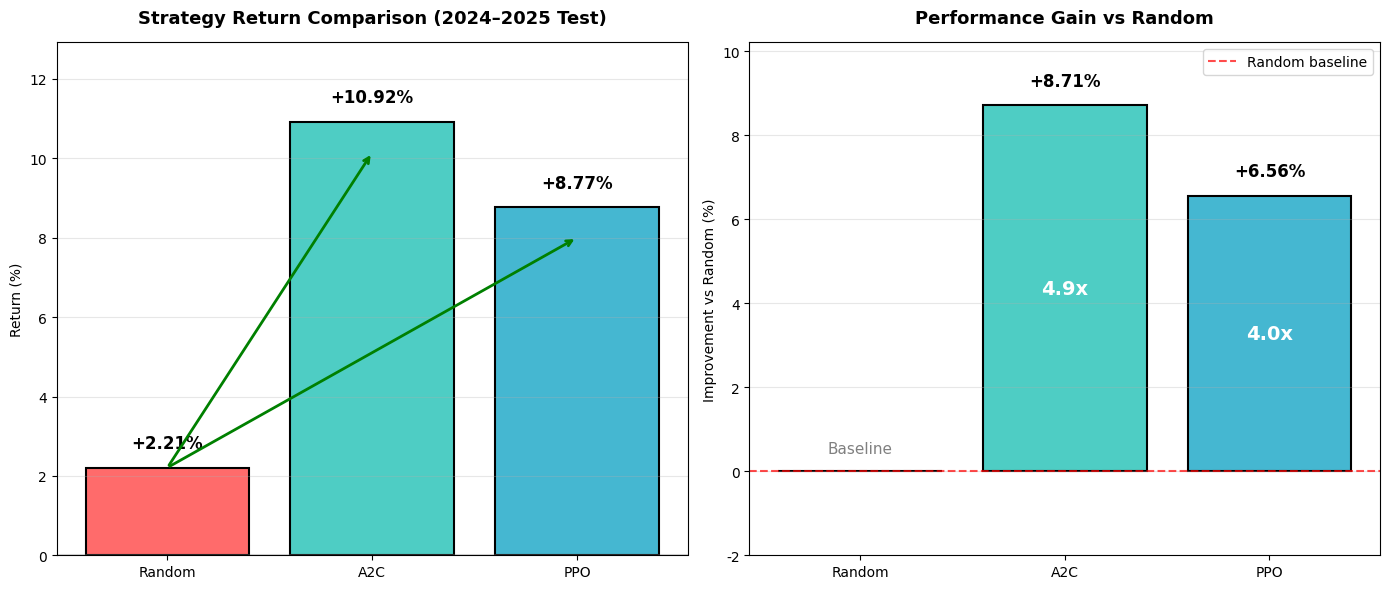

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

strategies = list(results.keys())
return_rates = [(np.mean(results[k]['profits']) - 1) * 100 for k in strategies]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
x = np.arange(len(strategies))

# ---------- Left: Return comparison ----------
ax1 = axes[0]
bars1 = ax1.bar(x, return_rates, color=colors, edgecolor='black', linewidth=1.5)

# ✅ Top padding: auto-expand by 15% of max value (at least +2)
max_r = max(return_rates)
top_pad = max(2.0, max_r * 0.15)
ax1.set_ylim(min(0, min(return_rates) - 2), max_r + top_pad)

# ✅ Label offset: auto-calculate based on chart height, won't stick to title
y_range = ax1.get_ylim()[1] - ax1.get_ylim()[0]
label_offset = y_range * 0.03

for bar, rate in zip(bars1, return_rates):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + label_offset,
             f'{rate:+.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# ✅ Arrow endpoint slightly lower, avoid competing with labels
arrow_drop = y_range * 0.06
if len(return_rates) > 1:
    ax1.annotate('', xy=(x[1], return_rates[1] - arrow_drop), xytext=(x[0], return_rates[0]),
                 arrowprops=dict(arrowstyle='->', color='green', lw=2))
if len(return_rates) > 2:
    ax1.annotate('', xy=(x[2], return_rates[2] - arrow_drop), xytext=(x[0], return_rates[0]),
                 arrowprops=dict(arrowstyle='->', color='green', lw=2))

ax1.set_xticks(x)
ax1.set_xticklabels(strategies)
ax1.set_ylabel('Return (%)')
# ✅ Title with padding, away from chart content
ax1.set_title('Strategy Return Comparison (2024–2025 Test)', pad=14, fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# ---------- Right: Improvement vs Random ----------
ax2 = axes[1]
baseline = return_rates[0]
improvements = [r - baseline for r in return_rates]
improvements[0] = 0

bars2 = ax2.bar(x, improvements, color=['#CCCCCC', '#4ECDC4', '#45B7D1'],
               edgecolor='black', linewidth=1.5)

# ✅ Right chart also has padding
max_imp = max(improvements)
top_pad2 = max(1.5, max_imp * 0.15)
ax2.set_ylim(min(-2, min(improvements) - 1), max_imp + top_pad2)

y_range2 = ax2.get_ylim()[1] - ax2.get_ylim()[0]
label_offset2 = y_range2 * 0.03

for bar, imp in zip(bars2, improvements):
    h = bar.get_height()
    if imp > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., h + label_offset2,
                 f'{imp:+.2f}%',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
    else:
        ax2.text(bar.get_x() + bar.get_width()/2., h + label_offset2,
                 'Baseline',
                 ha='center', va='bottom', fontsize=11, color='gray')

ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Random baseline')
ax2.set_xticks(x)
ax2.set_xticklabels(strategies)
ax2.set_ylabel('Improvement vs Random (%)')
ax2.set_title('Performance Gain vs Random', pad=14, fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

# ✅ Multiplier annotation: place in middle of bar, won't overlap with top labels
if baseline != 0:
    for i in range(1, len(strategies)):
        ratio = return_rates[i] / baseline
        ax2.text(x[i], improvements[i] * 0.5, f'{ratio:.1f}x',
                 ha='center', va='center', fontsize=14, fontweight='bold', color='white')

plt.tight_layout()
plt.show()


## 8. Trading Visualization

In [16]:
def visualize_trading_t1(model, env, model_name, seed=42):
    """Visualize trading strategy - show buy/sell points"""
    obs, _ = env.reset(seed=seed)
    done = False

    while not done:
        if model is not None:
            action, _ = model.predict(obs, deterministic=True)
        else:
            action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    # Use new rendering method to show buy/sell points
    fig = env.render_with_trades(title=f'{model_name} (2024-2025 T+1)')
    plt.show()

    # Print trade details
    print(f"\n{model_name} Trade Statistics:")
    print(f"  Buy count: {len(info['buy_ticks'])}")
    print(f"  Sell count: {len(info['sell_ticks'])}")
    print(f"  Final profit: {info['total_profit']:.4f} ({(info['total_profit']-1)*100:.2f}%)")

    # Print each trade
    if info['buy_ticks'] and info['sell_ticks']:
        print(f"\n  Trade Details:")
        for i, (buy_t, sell_t) in enumerate(zip(info['buy_ticks'], info['sell_ticks'])):
            buy_p = env.prices[buy_t]
            sell_p = env.prices[sell_t]
            pnl = (sell_p - buy_p) / buy_p * 100
            hold_days = sell_t - buy_t
            print(f"    Trade #{i+1}: Buy@{buy_p:.0f} -> Sell@{sell_p:.0f}, Profit{pnl:+.2f}%, Held{hold_days} days")

    return info

随机策略 (T+1)


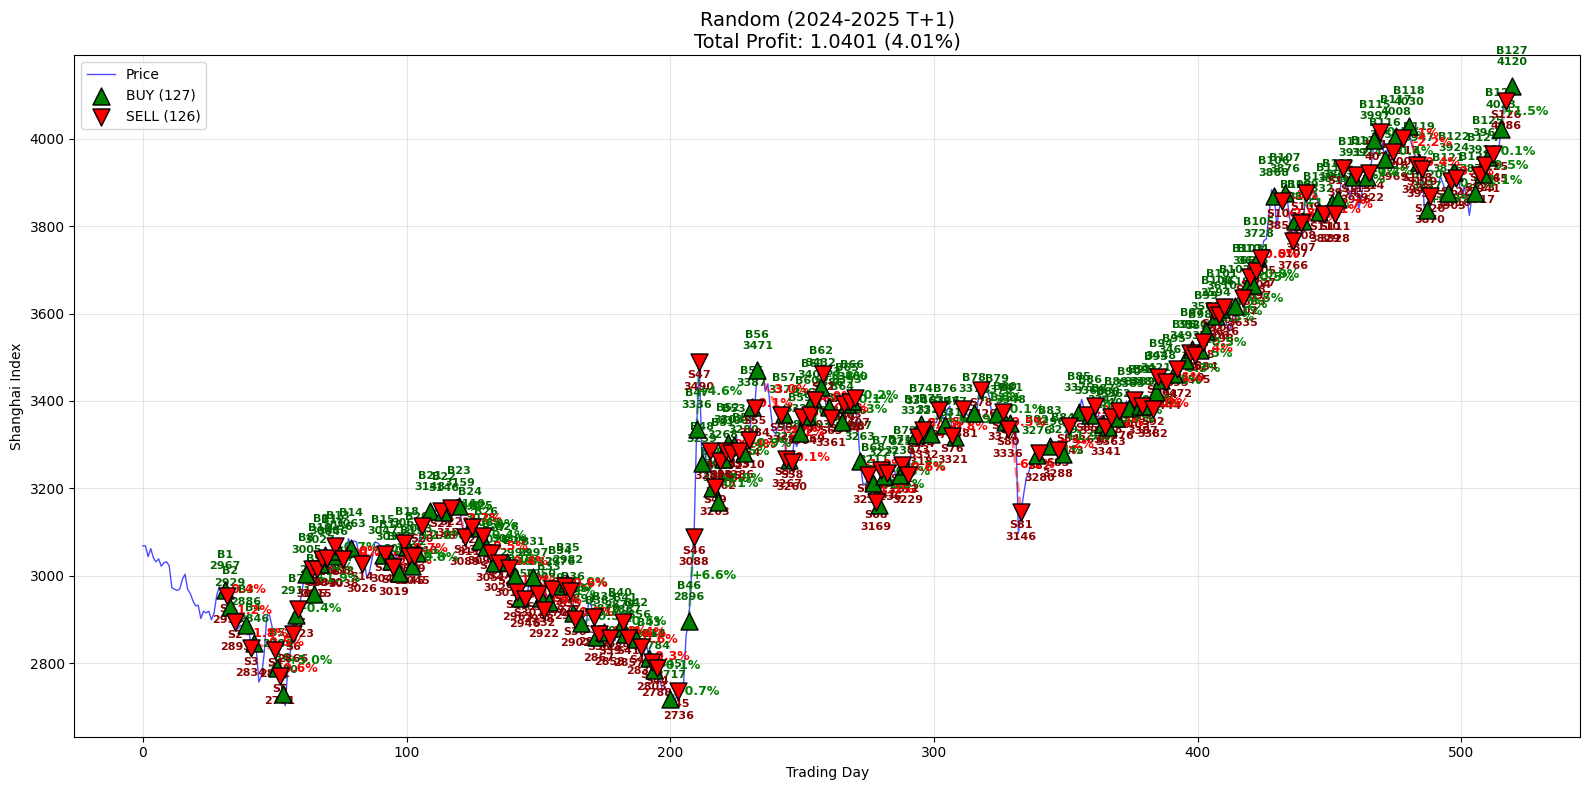


Random 交易统计:
  买入次数: 127
  卖出次数: 126
  最终收益: 1.0401 (4.01%)

  交易明细:
    第1笔: 买入@2967 -> 卖出@2954, 收益-0.43%, 持有1天
    第2笔: 买入@2929 -> 卖出@2893, 收益-1.23%, 持有2天
    第3笔: 买入@2886 -> 卖出@2834, 收益-1.82%, 持有2天
    第4笔: 买入@2846 -> 卖出@2831, 收益-0.54%, 持有8天
    第5笔: 买入@2789 -> 卖出@2771, 收益-0.64%, 持有1天
    第6笔: 买入@2730 -> 卖出@2866, 收益+4.97%, 持有4天
    第7笔: 买入@2911 -> 卖出@2923, 收益+0.42%, 持有1天
    第8笔: 买入@3005 -> 卖出@3015, 收益+0.35%, 持有2天
    第9笔: 买入@2958 -> 卖出@3015, 收益+1.94%, 持有1天
    第10笔: 买入@3027 -> 卖出@3039, 收益+0.41%, 持有1天
    第11笔: 买入@3048 -> 卖出@3040, 收益-0.26%, 持有1天
    第12笔: 买入@3046 -> 卖出@3068, 收益+0.74%, 持有1天
    第13笔: 买入@3056 -> 卖出@3038, 收益-0.58%, 持有2天
    第14笔: 买入@3063 -> 卖出@3026, 收益-1.19%, 持有4天
    第15笔: 买入@3047 -> 卖出@3049, 收益+0.05%, 持有1天
    第16笔: 买入@3034 -> 卖出@3019, 收益-0.49%, 持有1天
    第17笔: 买入@3007 -> 卖出@3074, 收益+2.23%, 持有2天
    第18笔: 买入@3065 -> 卖出@3045, 收益-0.67%, 持有1天
    第19笔: 买入@3022 -> 卖出@3045, 收益+0.76%, 持有1天
    第20笔: 买入@3053 -> 卖出@3113, 收益+1.97%, 持有2天
    第21笔: 买入@3148 -> 卖出@3148, 收益+0.01%,

In [17]:
# Visualize each strategy - show buy/sell points
print("=" * 60)
print("Random Strategy (T+1)")
print("=" * 60)
_ = visualize_trading_t1(None, test_env, 'Random')

A2C 策略 (T+1)


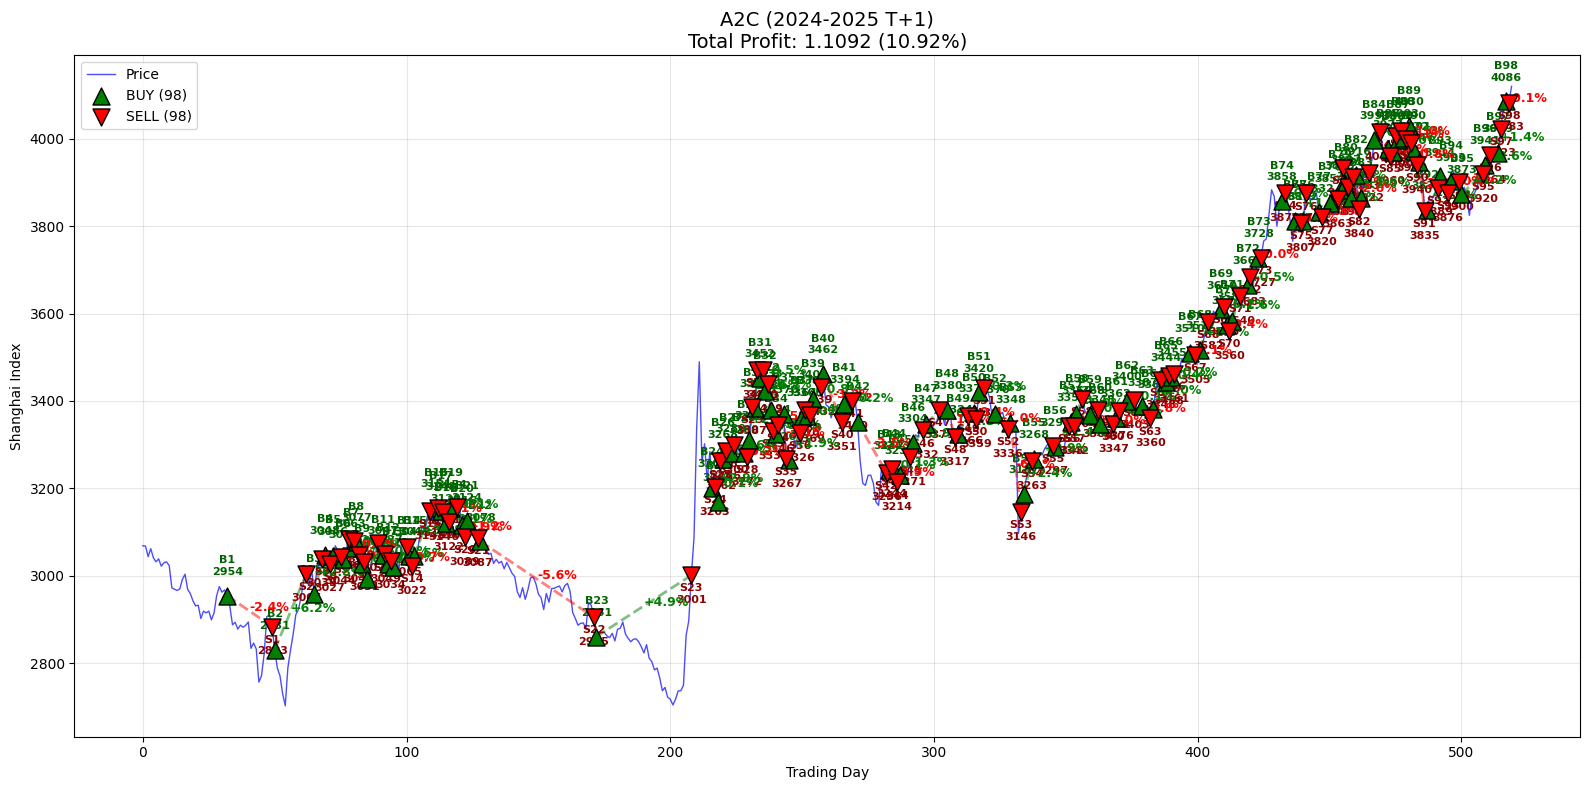


A2C 交易统计:
  买入次数: 98
  卖出次数: 98
  最终收益: 1.1092 (10.92%)

  交易明细:
    第1笔: 买入@2954 -> 卖出@2883, 收益-2.40%, 持有17天
    第2笔: 买入@2831 -> 卖出@3005, 收益+6.16%, 持有12天
    第3笔: 买入@2958 -> 卖出@3039, 收益+2.75%, 持有3天
    第4笔: 买入@3048 -> 卖出@3027, 收益-0.67%, 持有2天
    第5笔: 买入@3046 -> 卖出@3044, 收益-0.07%, 持有3天
    第6笔: 买入@3038 -> 卖出@3085, 收益+1.54%, 持有2天
    第7笔: 买入@3063 -> 卖出@3080, 收益+0.55%, 持有1天
    第8笔: 买入@3077 -> 卖出@3048, 收益-0.95%, 持有1天
    第9笔: 买入@3026 -> 卖出@3031, 收益+0.17%, 持有1天
    第10笔: 买入@2993 -> 卖出@3075, 收益+2.73%, 持有4天
    第11笔: 买入@3047 -> 卖出@3049, 收益+0.05%, 持有1天
    第12笔: 买入@3027 -> 卖出@3034, 收益+0.23%, 持有1天
    第13笔: 买入@3019 -> 卖出@3065, 收益+1.52%, 持有5天
    第14笔: 买入@3045 -> 卖出@3022, 收益-0.74%, 持有1天
    第15笔: 买入@3045 -> 卖出@3148, 收益+3.38%, 持有6天
    第16笔: 买入@3154 -> 卖出@3155, 收益+0.01%, 持有1天
    第17笔: 买入@3148 -> 卖出@3146, 收益-0.07%, 持有1天
    第18笔: 买入@3120 -> 卖出@3122, 收益+0.08%, 持有1天
    第19笔: 买入@3154 -> 卖出@3158, 收益+0.12%, 持有2天
    第20笔: 买入@3116 -> 卖出@3089, 收益-0.88%, 持有1天
    第21笔: 买入@3124 -> 卖出@3087, 收益-1.19%, 持

In [18]:
print("=" * 60)
print("A2C Strategy (T+1)")
print("=" * 60)
_ = visualize_trading_t1(a2c_model, test_env, 'A2C')

PPO 策略 (T+1)


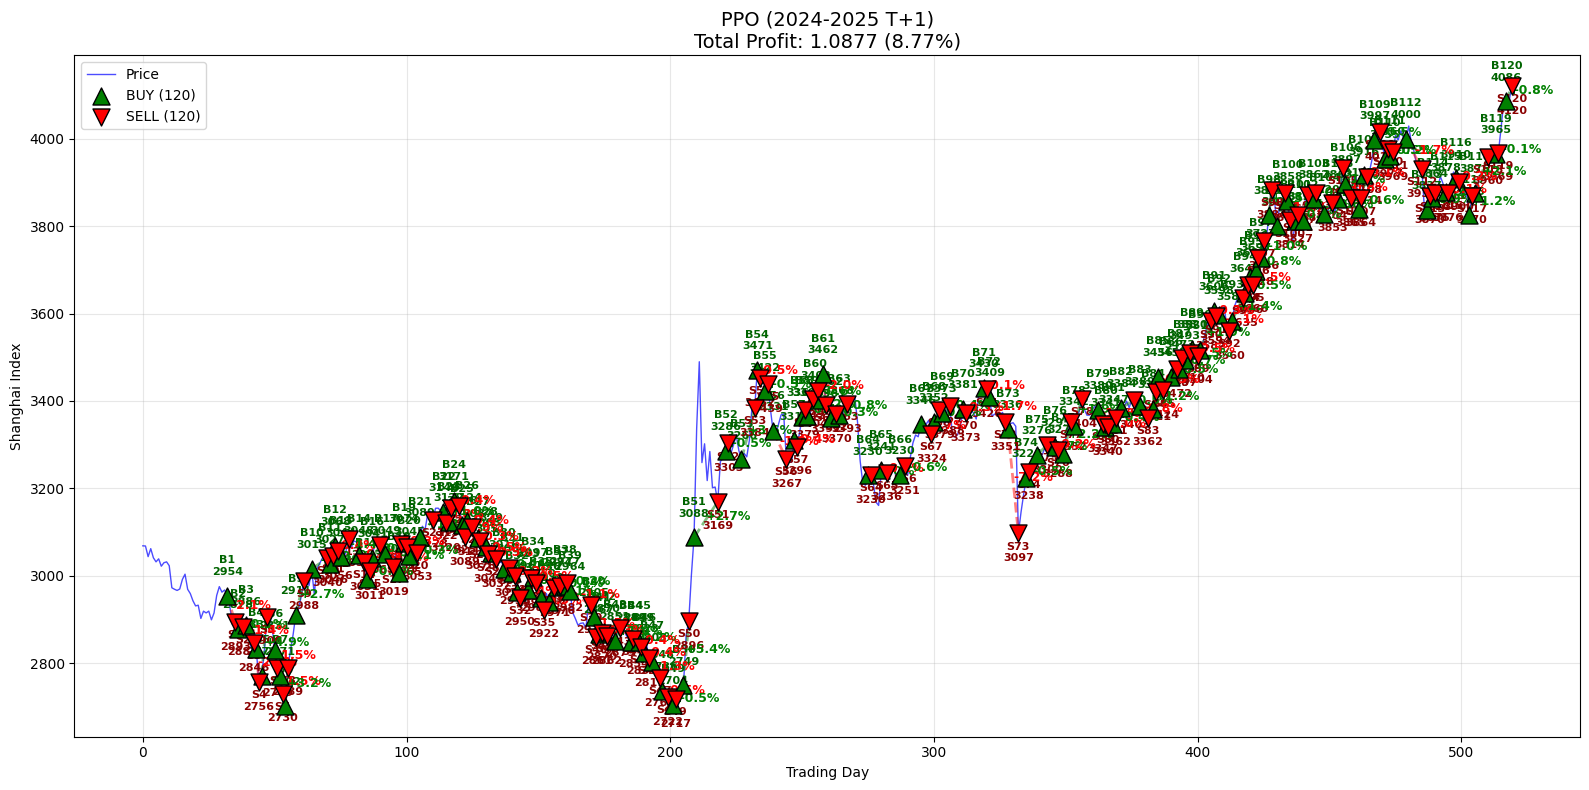


PPO 交易统计:
  买入次数: 120
  卖出次数: 120
  最终收益: 1.0877 (8.77%)

  交易明细:
    第1笔: 买入@2954 -> 卖出@2893, 收益-2.07%, 持有3天
    第2笔: 买入@2878 -> 卖出@2882, 收益+0.15%, 持有2天
    第3笔: 买入@2886 -> 卖出@2846, 收益-1.40%, 持有3天
    第4笔: 买入@2832 -> 卖出@2756, 收益-2.68%, 持有1天
    第5笔: 买入@2771 -> 卖出@2906, 收益+4.88%, 持有2天
    第6笔: 买入@2831 -> 卖出@2789, 收益-1.48%, 持有1天
    第7笔: 买入@2771 -> 卖出@2730, 收益-1.46%, 持有1天
    第8笔: 买入@2702 -> 卖出@2789, 收益+3.23%, 持有1天
    第9笔: 买入@2911 -> 卖出@2988, 收益+2.67%, 持有3天
    第10笔: 买入@3015 -> 卖出@3040, 收益+0.81%, 持有6天
    第11笔: 买入@3027 -> 卖出@3046, 收益+0.62%, 持有1天
    第12笔: 买入@3068 -> 卖出@3056, 收益-0.41%, 持有1天
    第13笔: 买入@3044 -> 卖出@3085, 收益+1.35%, 持有3天
    第14笔: 买入@3048 -> 卖出@3031, 收益-0.54%, 持有2天
    第15笔: 买入@2993 -> 卖出@3011, 收益+0.59%, 持有1天
    第16笔: 买入@3041 -> 卖出@3069, 收益+0.92%, 持有3天
    第17笔: 买入@3049 -> 卖出@3019, 收益-0.95%, 持有3天
    第18笔: 买入@3007 -> 卖出@3071, 收益+2.14%, 持有1天
    第19笔: 买入@3074 -> 卖出@3065, 收益-0.29%, 持有1天
    第20笔: 买入@3045 -> 卖出@3053, 收益+0.27%, 持有3天
    第21笔: 买入@3089 -> 卖出@3128, 收益+1.29%, 持有

In [19]:
print("=" * 60)
print("PPO Strategy (T+1)")
print("=" * 60)
_ = visualize_trading_t1(ppo_model, test_env, 'PPO')

## 9. Results Summary

In [20]:
# Results summary table
summary = []
for name in results.keys():
    profits = results[name]['profits']
    summary.append({
        'Strategy': name,
        'Avg Profit': f"{np.mean(profits):.4f}",
        'Return Rate': f"{(np.mean(profits)-1)*100:.2f}%",
        'Max': f"{np.max(profits):.4f}",
        'Min': f"{np.min(profits):.4f}",
        'Std Dev': f"{np.std(profits):.4f}"
    })

summary_df = pd.DataFrame(summary)
print("\n" + "=" * 70)
print("                    2024-2025 Test Results Summary")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

# Best Strategy
best = max(results.keys(), key=lambda x: np.mean(results[x]['profits']))
best_profit = np.mean(results[best]['profits'])
print(f"\nBestStrategy: {best}")
print(f"AverageReturn rate: {(best_profit-1)*100:.2f}%")
print(f"Test Period: 2024-01-02 to 2026-01-09")
print(f"Training Steps: {TOTAL_TIMESTEPS}")



                    2024-2025 测试结果汇总
    策略   平均收益    收益率     最高     最低    标准差
Random 1.0221  2.21% 1.2579 0.7904 0.1265
   A2C 1.1092 10.92% 1.1092 1.1092 0.0000
   PPO 1.0877  8.77% 1.0877 1.0877 0.0000

最佳策略: A2C
平均收益率: 10.92%
测试期间: 2024-01-02 至 2026-01-09
训练步数: 100000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
import datetime
print(f"cuurent time: {datetime.datetime.now()}")

cuurent time: 2026-01-28 22:14:00.269524
